# Server's Log

In [1]:
import json
offical_run = json.load(open("LSC24 Official Expert.json"))
# 'id', 'name', 'description', 'started', 'ended', 'tasks', 'hasStarted', 'running', 'hasEnded'

In [2]:
tasks = offical_run['template']['tasks']
targets = {}
queries = {}
task_id_to_name = {}
for i in range(len(tasks)):
    task_id_to_name[tasks[i]['id']] = tasks[i]['name']
    targets[tasks[i]['name']] = []
    queries[tasks[i]['name']] = [item['description'] for item in tasks[i]['hints']]

56 56


In [11]:
teams = offical_run['template']['teams']
team_ids = {item["id"]: item["name"] for item in teams}

In [12]:
from collections import defaultdict

TEAMS = list(team_ids.values())
TASKS = ["KIS", "QA", "AD"]

def task_type(name):
    if "QA" in name:
        return "QA"
    elif "KIS" in name:
        return "KIS"
    return "AD"

def make_task_dicts(data_type):
    # deep copy obj to 3 keys: AD, QA, KIS
    return {task: defaultdict(data_type) for task in TASKS}

In [15]:
tasks = offical_run['tasks']
print("Number of tasks: ", len(tasks))

submissions = {}
start_times = {}
names = []
real_queries = []
real_targets = []
for i in range(len(tasks)):
    name = task_id_to_name[tasks[i]["templateId"]]
    if name in queries:
        if name.endswith("N"): # ignore novice
            continue
        names.append(name)
        real_queries.append(queries[name])
        real_targets.append(targets[name])
        start_times[name] = tasks[i]["started"]
        if task_type(name) != "QA":
            submissions[name] = [(item["teamName"],
                            item["answers"][0]["status"],
                            (item["timestamp"] - start_times[name])/1000,
                            item["answers"][0]["answers"][0]["item"]["name"]) for item in tasks[i]['submissions']]
        else:
            submissions[name] = [(item["teamName"],
                            item["answers"][0]["status"],
                            (item["timestamp"]- start_times[name])/1000,
                            item["answers"][0]["answers"][0]["text"]) for item in tasks[i]['submissions']]
print(names)

Number of tasks:  16
['LSC24-KISJ02', 'LSC24-AD01', 'LSC24-QA01', 'LSC24-KISJ03', 'LSC24-AD02', 'LSC24-QA02', 'LSC24-KIS04', 'LSC24-KISJ04', 'LSC24-AD03', 'LSC24-QA03', 'LSC24-KISJ05', 'LSC24-AD04', 'LSC24-QA04', 'LSC24-KISJ06', 'LSC24-AD05', 'LSC24-QA05']


## Correct/Incorrect

In [23]:
from collections import defaultdict
import numpy as np
correct_counts = make_task_dicts(int)
incorrect_counts = make_task_dicts(int)
total_counts = make_task_dicts(int)
time_till_correct = defaultdict(lambda: defaultdict(lambda: np.inf))
time_till_correct_full = defaultdict(lambda: defaultdict(lambda: 300))
top_3 = make_task_dicts(int)
limits = {"QA": 180, "KIS": 300, "AD": 180}

for team in TEAMS:
    for name in names:
        time_till_correct_full[team][name] = limits[task_type(name)]

for name in submissions:
    correct_time = 0
    task = task_type(name) 
    for team, status, time, image in submissions[name]:
        if status == "CORRECT":
            correct_counts[task][team] += 1
            time = min(time, limits[task])
            time_till_correct[team][name] = min(time_till_correct[team][name], time)
            time_till_correct_full[team][name] = min(time_till_correct_full[team][name], time)

            correct_time += 1
            if correct_time <= 3:
                top_3[task][team] += 1
        else:
            incorrect_counts[task][team] += 1

        total_counts[task][team] += 1

### Scoring

In [24]:
import math
import numpy as np
# Scores for each queries
max_point = 100
max_point_end = 50
penalty = 10
scores = {"QA": [],
          "AD": [],
          "KIS": []}
recall_ad = defaultdict(list)
precision_ad = defaultdict(list)

for name, submission in submissions.items():
    task = task_type(name)
    if task != "QA":
        correct = defaultdict(int)
        incorrect = defaultdict(int)
        score = defaultdict(float)
        num_correct = set()
        penalty = 0.2
        
        max_time = 180
        for team, status, time, image in submission:
            if status == "WRONG":
                incorrect[team] += 1
            elif status == "CORRECT":
                correct[team] += 1
                num_correct.add(image)
                
        for team in TEAMS:
            if correct[team] == 0:
                score[team] = 0
                recall_ad[team].append(0)
                precision_ad[team].append(0)
            else:
                score[team] = correct[team] * max_point / (correct[team] + incorrect[team]/2) * correct[team] / len(num_correct)
                recall_ad[team].append(correct[team] / len(num_correct))
                precision_ad[team].append(correct[team] / (correct[team] + incorrect[team]))
    else:
        score = defaultdict(float)
        for team, status, time, image in submission:
            if status == "WRONG":
                score[team] -= penalty
            elif status == "CORRECT":
                score[team] += max_point_end + (max_point - max_point_end) * (1 - time/limits[task])
        for team in TEAMS:
            score[team] = max(0, score[team])
    scores[task].append(score)

precision_ad = {team: np.mean(precision_ad[team]) for team in TEAMS}
recall_ad = {team: np.mean(recall_ad[team]) for team in TEAMS}


In [25]:
from collections import defaultdict, OrderedDict
TASKS = ["KIS", "QA", "AD"]
normalize_scores = {"QA": {},
                    "AD": {},
                    "KIS": {},
                    "SUM": defaultdict(float)}
for task in TASKS:
    cum_scores = defaultdict(float)
    for score in scores[task]: # iterate over all tasks in this task_type
        for team in score:
            cum_scores[team] += score[team]
                
    max_score = max(cum_scores.values())
    for team in cum_scores:
        normalize_scores[task][team] = round(cum_scores[team]/max_score * 100)
        normalize_scores["SUM"][team] += normalize_scores[task][team]
        
# sort TEAMS by normalize_scores
TEAMS = sorted(TEAMS, key=lambda team: normalize_scores["SUM"][team], reverse=True)
for task in TASKS:
    # sort dict by TEAMS
    normalize_scores[task] = OrderedDict(sorted(normalize_scores[task].items(), key=lambda x: TEAMS.index(x[0])))
print([(team, normalize_scores["SUM"][team]) for team in TEAMS])

[('LIFEXPLORE1', 260.0), ('SnapSeek1', 252.0), ('LIFEXPLORE2', 246.0), ('Libro1', 234.0), ('Exquisitor', 234.0), ('VISIONE1', 232.0), ('PraK1', 218.0), ('VISIONE3', 206.0), ('LIFEXPLORE3', 202.0), ('MemoriEase', 194.0), ('CollaXRSearch1', 189.0), ('LifeInsight', 180.0), ('SnapSeek2', 176.0), ('SnapSeek3', 170.0), ('Libro2', 166.0), ('SnapSeek5', 164.0), ('vitrivr-VR', 162.0), ('Retrospect1', 161.0), ('SnapSeek4', 161.0), ('PraK2', 156.0), ('Memento', 150.0), ('MEMORIA', 148.0), ('LifeSeeker1', 140.0), ('Libro3', 138.0), ('MyEachtra', 135.0), ('vitrivr', 134.0), ('EAGLE1', 128.0), ('VitaChronicle1', 125.0), ('VISIONE2', 121.0), ('Lifegraph', 119.0), ('PraK3', 114.0), ('EAGLE2', 114.0), ('LifeLens1', 101.0), ('Voxento', 87.0), ('LifeSeeker2', 45.0), ('Retrospect2', 0.0), ('LifeLens2', 0.0), ('CollaXRSearch2', 0.0), ('VitaChronicle2', 0.0), ('VitaChronicle3', 0.0)]


# GRAPHS

In [36]:
import pandas as pd
import seaborn as sns


df = None
for task in TASKS:
    data = {
        "team": TEAMS,
        "task": [f"{task}" for team in TEAMS],
        f"correct": [correct_counts[task][team] for team in TEAMS],
        f"incorrect": [incorrect_counts[task][team] for team in TEAMS],
        
        # f"cum_score_{task}": [cum_scores[task][team] for team in TEAMS],
        f"norm_score": [normalize_scores[task][team] for team in TEAMS],
    }
    if task != "AD":
        data.update({
            f"top_3": [top_3[task][team] for team in TEAMS],
            # f"precision": [correct_counts[task][team]/total_counts[task][team] for team in TEAMS],
            f"recall": [correct_counts[task][team]/len(scores[task]) for team in TEAMS]})
    else:
        data["recall"] = [recall_ad[team] for team in TEAMS]
        data["precision"] = [precision_ad[team] for team in TEAMS]
    for i in time_till_correct["MyEachtra"]:
        data[f"time_correct_{i}"] = [time_till_correct[team][i] for team in TEAMS]
    for i in time_till_correct_full["MyEachtra"]:
        data[f"time_correct_full_{i}"] = [time_till_correct_full[team][i] for team in TEAMS]
    if df is None:
        df = pd.DataFrame(data=data)
    else:
        df = pd.concat([df, pd.DataFrame(data=data)], axis=0)   

assert df is not None, "df is None"
# Remove teams with 0 scores on all tasks
df = df[df["norm_score"] > 0]
df

,team,task,correct,incorrect,norm_score,top_3,recall,time_correct_LSC24-KISJ03,time_correct_LSC24-QA02,time_correct_LSC24-AD03,...,time_correct_full_LSC24-KISJ04,time_correct_full_LSC24-AD03,time_correct_full_LSC24-QA03,time_correct_full_LSC24-KISJ05,time_correct_full_LSC24-AD04,time_correct_full_LSC24-QA04,time_correct_full_LSC24-KISJ06,time_correct_full_LSC24-AD05,time_correct_full_LSC24-QA05,precision
0,LIFEXPLORE1,KIS,5,3,94,1.0,0.833333,187.391,38.723,23.254,...,7.694,23.254,17.331,93.432,52.229,49.273,77.969,19.924,70.655,NaN
1,SnapSeek1,KIS,6,0,100,0.0,1.000000,177.263,52.759,67.105,...,28.804,67.105,40.222,132.188,34.799,180.000,162.683,23.329,180.000,NaN
2,LIFEXPLORE2,KIS,5,0,97,1.0,0.833333,232.345,26.349,78.444,...,21.566,78.444,17.492,80.617,37.286,180.000,32.578,19.373,41.260,NaN
3,Libro1,KIS,5,1,97,0.0,0.833333,201.286,62.313,54.083,...,17.533,54.083,23.983,79.473,49.182,148.371,64.200,45.716,45.040,NaN
4,Exquisitor,KIS,5,2,92,0.0,0.833333,214.261,180.000,36.612,...,155.440,36.612,21.061,90.338,23.291,180.000,74.162,12.801,34.096,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,PraK3,AD,25,14,26,NaN,0.174574,209.450,inf,60.515,...,300.000,60.515,33.689,99.802,180.000,180.000,300.000,46.176,75.218,0.534343
31,EAGLE2,AD,32,10,11,NaN,0.080958,inf,51.394,50.769,...,32.773,50.769,41.462,146.420,128.719,180.000,49.773,43.610,180.000,0.506629
32,LifeLens1,AD,115,22,27,NaN,0.070767,inf,98.077,inf,...,16.017,180.000,31.694,277.744,31.462,180.000,300.000,21.533,115.987,0.416754
33,Voxento,AD,81,8,17,NaN,0.070264,inf,78.300,32.480,...,45.110,32.480,180.000,297.728,82.488,73.140,300.000,22.237,76.590,0.570366


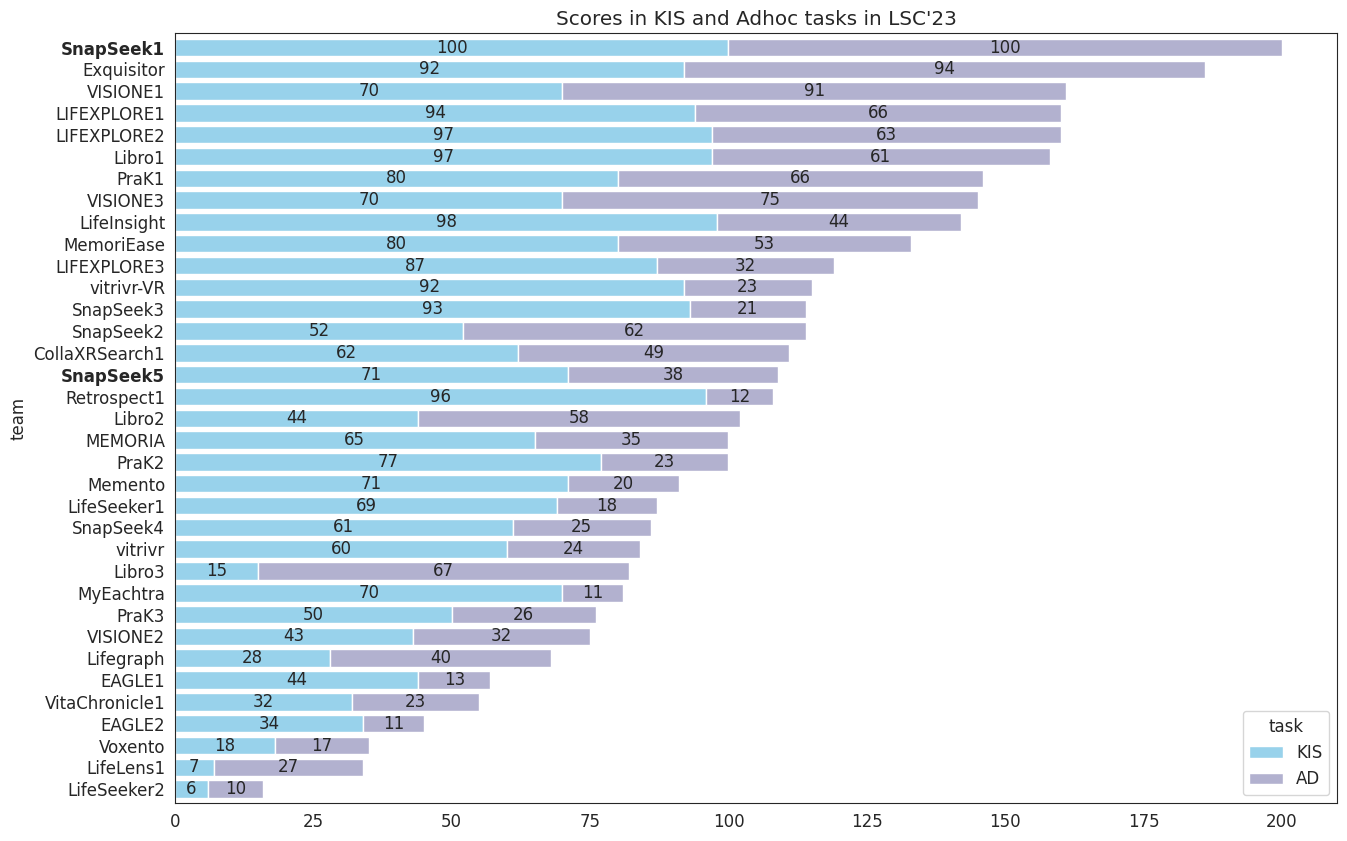

In [37]:
task_names = ["KIS", "AD"]
assert df is not None, "df is None"

import matplotlib.pyplot as plt

sns.set_style("white")
plt.rcParams.update({'font.size': 12})
all_score = df.groupby(['team', 'task']).sum().reset_index().pivot(index='team', columns='task', values='norm_score')

# Sort task by ["KIS", "AD", "AD"]
all_score = all_score.reindex(columns=task_names)

# sort by the sum of scores
sum_score = all_score.sum(axis=1)
all_score = all_score.loc[sum_score.sort_values(ascending=True).index]
fig = all_score.plot.barh(figsize=(15, 10), rot=0, stacked=True, 
                    title="Scores in KIS and Adhoc tasks in LSC'23", width=0.8,
                    color=["#98D2EB", "#B2B1CF", "#b0c5aa"], legend=True)

fig.bar_label(fig.containers[0], labels=all_score["KIS"], label_type='center') # type: ignore
# fig.bar_label(fig.containers[1], labels=all_score["QA"], label_type='center')
fig.bar_label(fig.containers[1], labels=all_score["AD"], label_type='center') # type: ignore

# Highlighting LifeXplore and vitrivr (for example)
fig.axes.get_yticklabels()[-1].set_fontweight("bold")
fig.axes.get_yticklabels()[-16].set_fontweight("bold")

plt.savefig("overall_23.png", format="png", bbox_inches='tight')

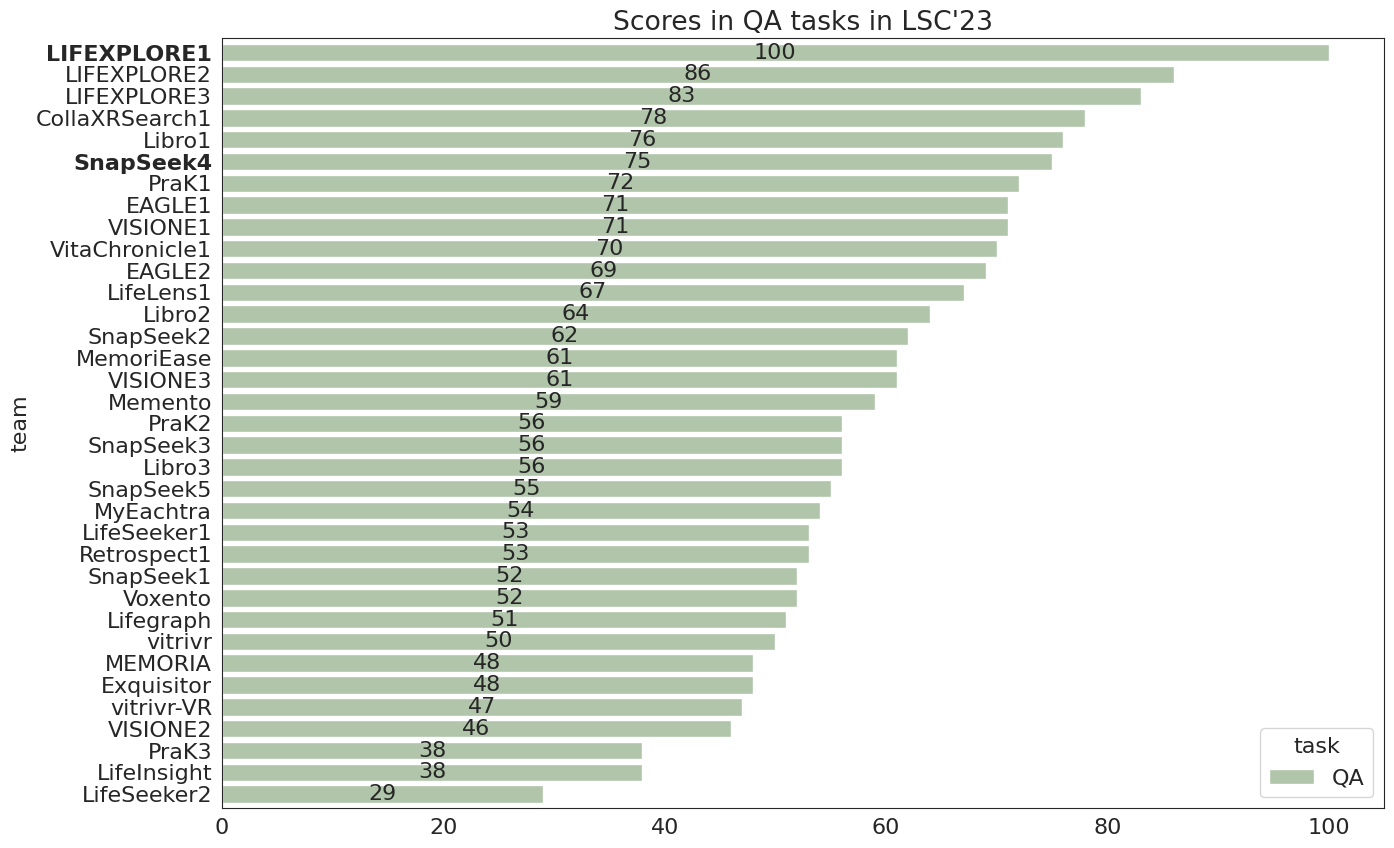

In [41]:
task_names = ["QA"]

import matplotlib.pyplot as plt

assert df is not None, "df is None"
sns.set_style("white")
plt.rcParams.update({'font.size': 16})
all_score = df.groupby(['team', 'task']).sum().reset_index().pivot(index='team', columns='task', values='norm_score')
# Sort task by ["KIS", "AD", "AD"]
all_score = all_score.reindex(columns=task_names)

# sort by the sum of scores
sum_score = all_score.sum(axis=1)
all_score = all_score.loc[sum_score.sort_values(ascending=True).index]
fig = all_score.plot.barh(figsize=(15, 10), rot=0, stacked=True, 
                    title="Scores in QA tasks in LSC'23", width=0.8,
                    color=["#b0c5aa"], legend=True)

fig.bar_label(fig.containers[0], labels=all_score["QA"], label_type='center')

# Highlighting MyEachtra and E-Mysceal by fontweight
fig.axes.get_yticklabels()[-1].set_fontweight("bold")
fig.axes.get_yticklabels()[-6].set_fontweight("bold")

plt.savefig("overall_qa_23.png", format="png", bbox_inches='tight')

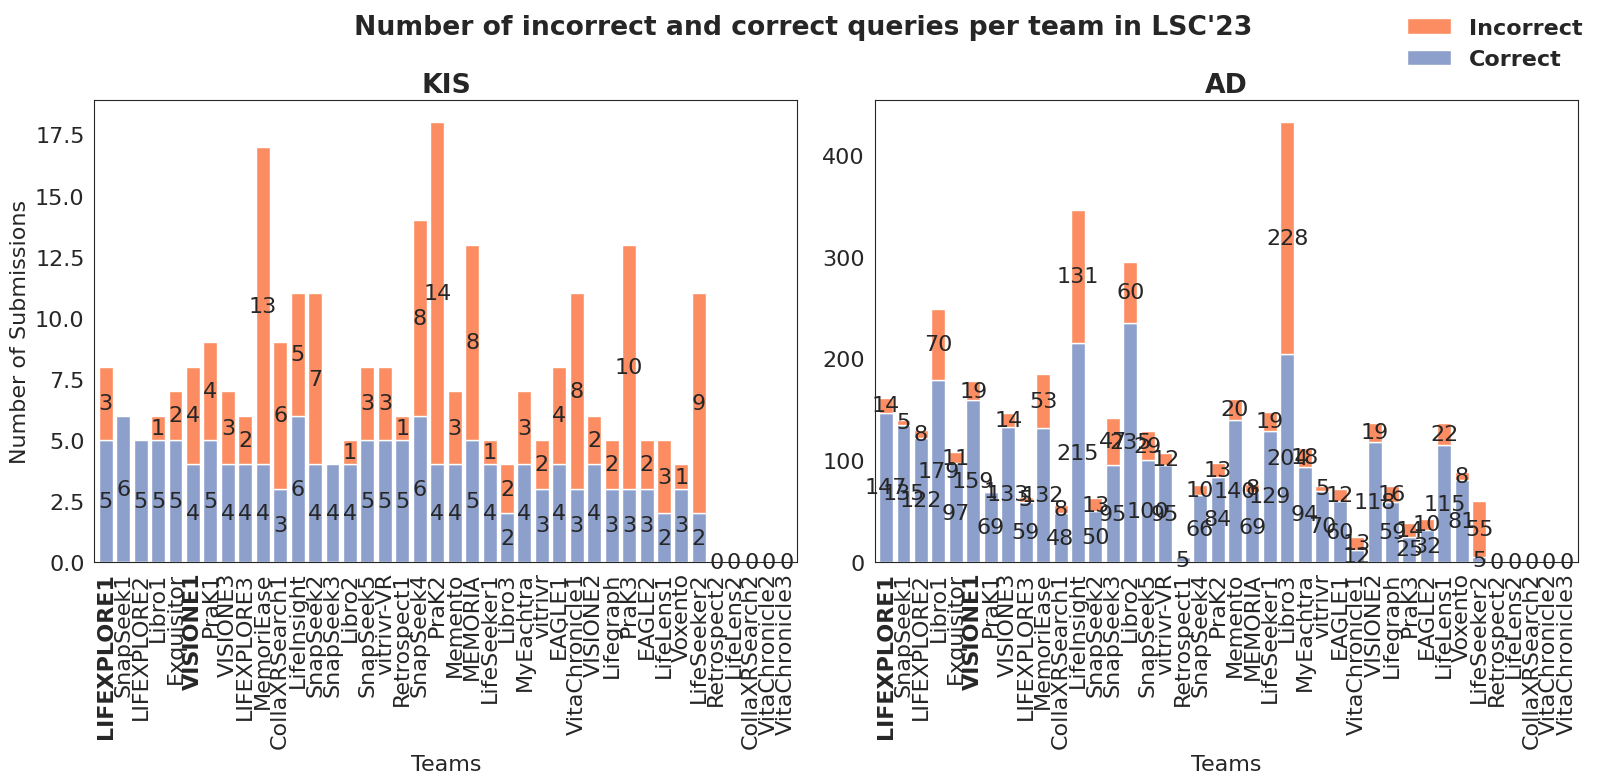

In [20]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16, 'figure.figsize': (20, 8)})
task_names = ["KIS", "AD"]
# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(16, 8))
# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, width=0.8, color=["#8da0cb", "#fc8d62"], ax=axes[i])
    ax.bar_label(ax.containers[0], labels=filtered["correct"], label_type='center')
    ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["incorrect"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Number of Submissions", va='center', rotation='vertical', transform=ax.transAxes)

    ax.get_xticklabels()[0].set_fontweight("bold")
    ax.get_xticklabels()[5].set_fontweight("bold")
    # make y-axis ends at 12
    # ax.set_ylim(0, 12)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[::-1], ["Incorrect", "Correct"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Number of incorrect and correct queries per team in LSC'23", fontweight='bold')
plt.tight_layout()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("incorrect_correct_23.png", format="pdf", bbox_inches='tight')

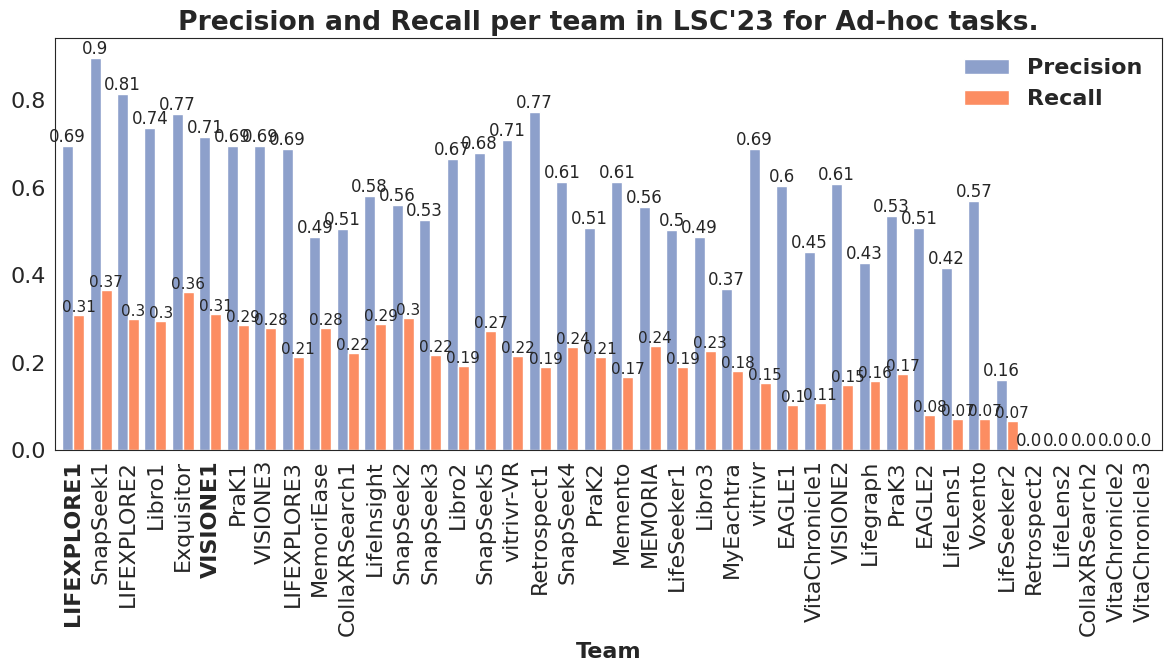

In [21]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (12, 7)

# Plot data for each TASK
filtered = df[df["task"] == "AD"]
fig = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#8da0cb", "#fc8d62"])
fig.bar_label(fig.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=12)
fig.bar_label(fig.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=11)

plt.xlabel("Team", fontweight='bold')
fig.axes.get_xticklabels()[0].set_fontweight("bold")
fig.axes.get_xticklabels()[5].set_fontweight("bold")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)

# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Precision and Recall per team in LSC'23 for Ad-hoc tasks.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("precision-recall_23.png", format="png", bbox_inches='tight')

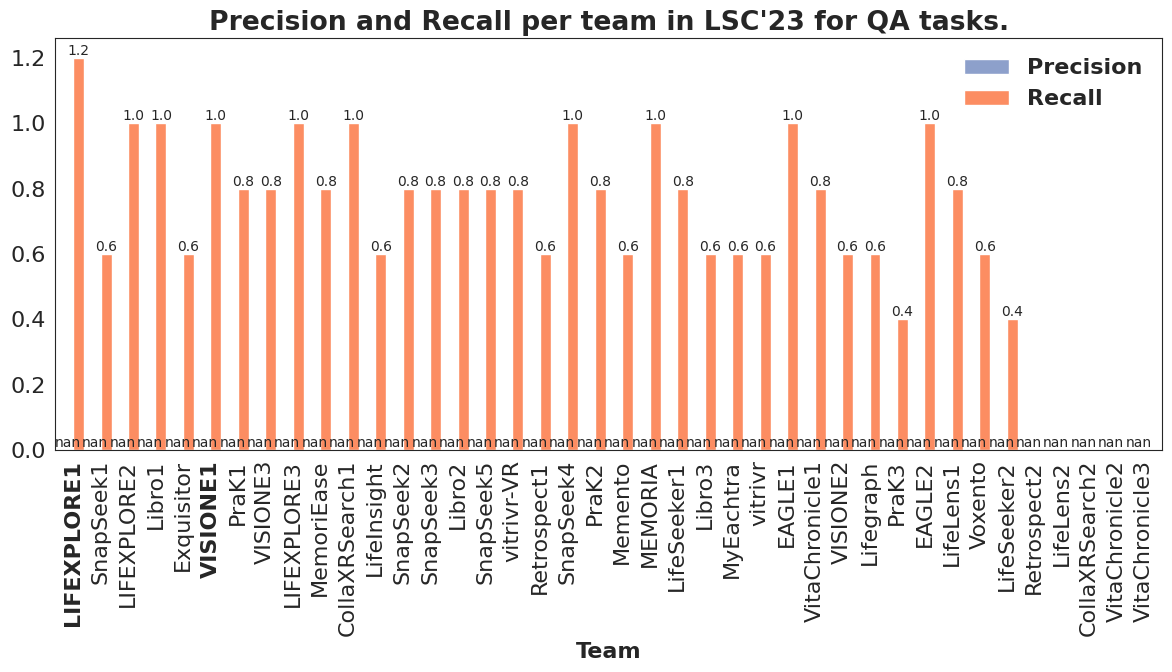

In [22]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (12, 7)

# Plot data for each TASK
filtered = df[df["task"] == "QA"]
fig = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#8da0cb", "#fc8d62"])
fig.bar_label(fig.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=10)
fig.bar_label(fig.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=10)

plt.xlabel("Team", fontweight='bold')
fig.axes.get_xticklabels()[0].set_fontweight("bold")
fig.axes.get_xticklabels()[5].set_fontweight("bold")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)

# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Precision and Recall per team in LSC'23 for QA tasks.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("precision-recall_23.png", format="png", bbox_inches='tight')

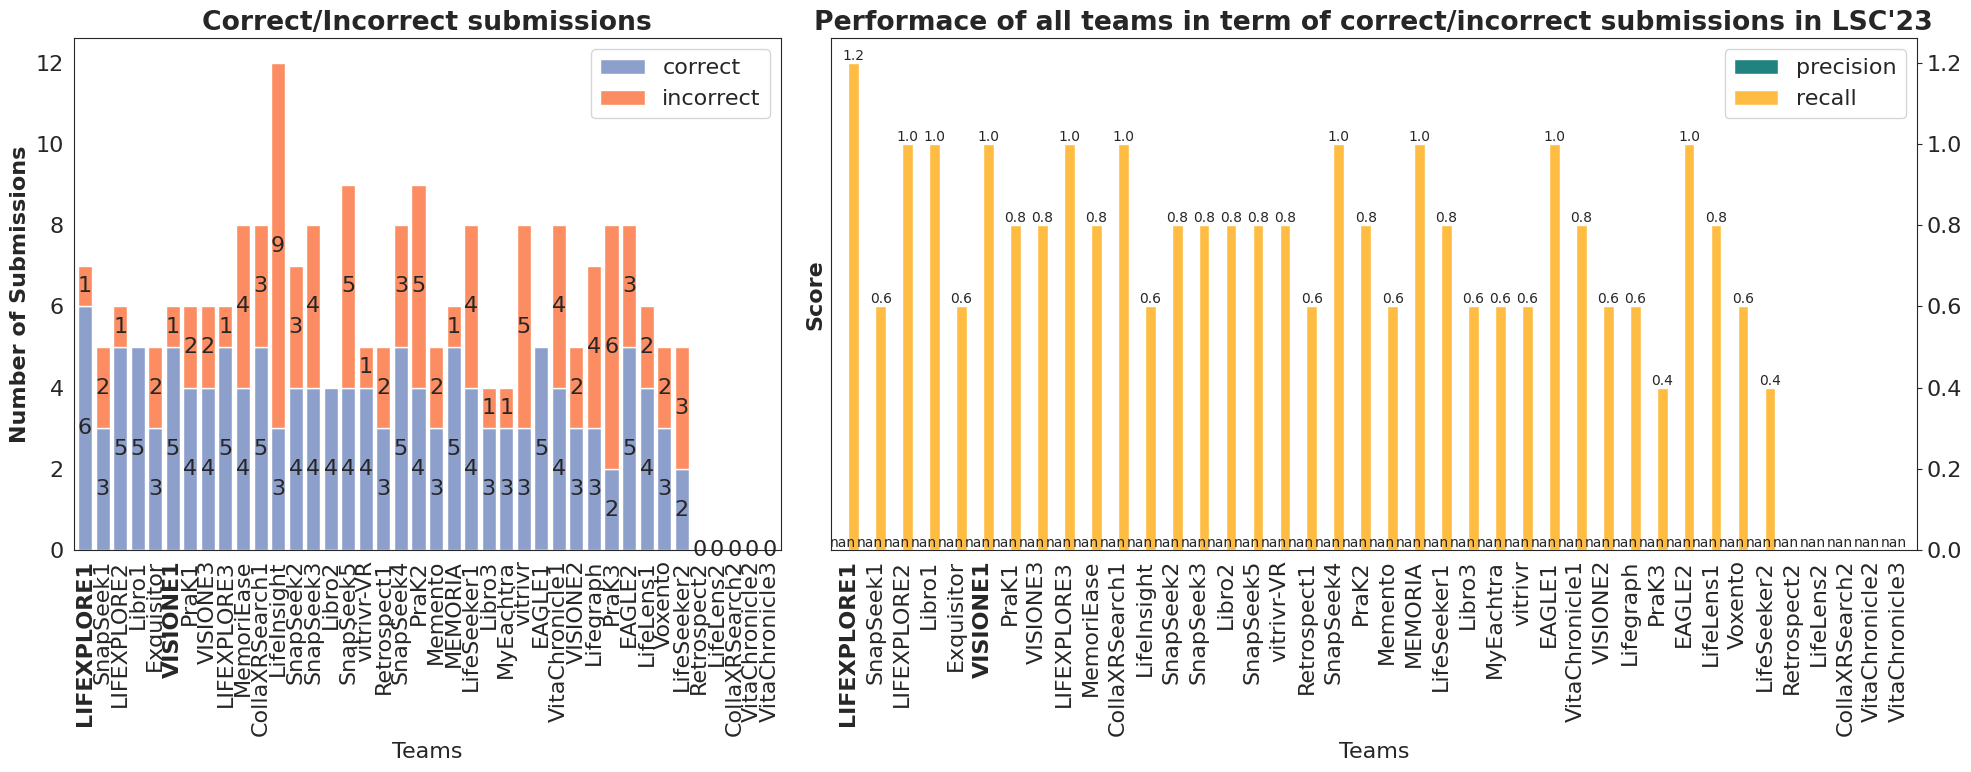

In [23]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16, 'figure.figsize': (20, 8)})
filtered = df[df["task"] == "QA"]
# Create subplots
# fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ================== Subplot 1 ================== #
i = 0 # Subplot 1, incorrect correct
plot1 = plt.subplot2grid((1, 5), (0, 0), colspan=2)

ax = filtered[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, width=0.8, color=["#8da0cb", "#fc8d62"], ax=plot1)
ax.bar_label(ax.containers[0], labels=filtered["correct"], label_type='center')
ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["incorrect"]], label_type='center')

ax.set_xlabel("Teams")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
ax.set_xticklabels(filtered["team"])
ax.set_ylabel("Number of Submissions", fontweight='bold')

ax.get_xticklabels()[0].set_fontweight("bold")
ax.get_xticklabels()[5].set_fontweight("bold")

# Title of the subplot
ax.set_title("Correct/Incorrect submissions", fontweight='bold')
# ================== Subplot 2 ================== #
i = 1
plot2 = plt.subplot2grid((1, 5), (0, 2), colspan=3)

ax = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#218380", "#FFBC42"], ax=plot2)

ax.bar_label(ax.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=10)
ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=10)

ax.set_xlabel("Teams")
ax.set_xticklabels(filtered["team"])
ax.yaxis.tick_right()
ax.set_ylabel("Score", fontweight='bold')

ax.get_xticklabels()[0].set_fontweight("bold")
ax.get_xticklabels()[5].set_fontweight("bold")
ax.set_title("Precision/Recall", fontweight='bold')

# Create a single legend for all subplots
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles[::-1], ["Incorrect", "Correct"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.title("Performace of all teams in term of correct/incorrect submissions in LSC'23", fontweight='bold')
plt.tight_layout()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("qa_23.png", format="png", bbox_inches='tight')

ValueError: The number of FixedLocator locations (14), usually from a call to set_ticks, does not match the number of labels (40).

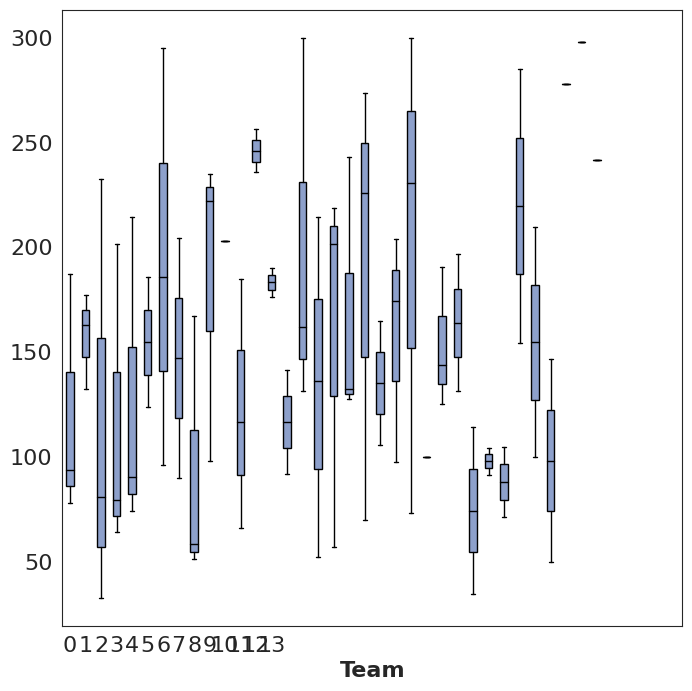

In [24]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (8, 8)

# Plot data for each TASK
filtered = df[df["task"] == "KIS"]
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "KIS"]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True)

plt.xlabel("Team", fontweight='bold')
plt.xticks(ticks=range(1, 15), labels=filtered["team"], rotation=90)
# set xtick label 0 and 6 in bold
plt.gca().get_xticklabels()[0].set_fontweight("bold")
plt.gca().get_xticklabels()[5].set_fontweight("bold")

# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)
plt.axhline(y=limits['KIS'], color='r', linestyle='-', label=f"Time limit: {limits['KIS']}s")
# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Time to correct submission for KIS task in LSC'23.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_23.png", format="png", bbox_inches='tight')

ValueError: The number of FixedLocator locations (14), usually from a call to set_ticks, does not match the number of labels (40).

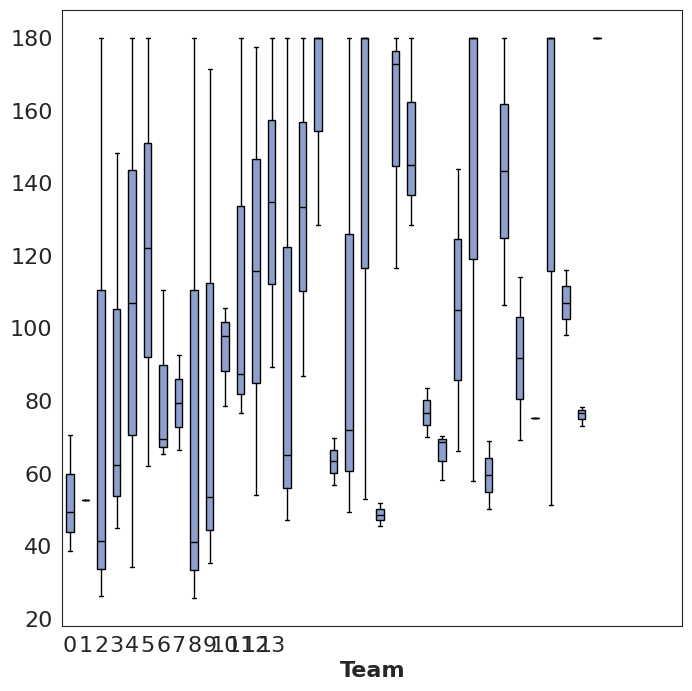

In [25]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (8, 8)

# Plot data for each TASK
filtered = df[df["task"] == "QA"]
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "QA"]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True)

plt.xlabel("Team", fontweight='bold')
plt.xticks(ticks=range(1, 15), labels=filtered["team"], rotation=90)
# set xtick label 0 and 6 in bold
plt.gca().get_xticklabels()[0].set_fontweight("bold")
plt.gca().get_xticklabels()[5].set_fontweight("bold")

# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)
plt.axhline(y=limits['QA'], color='r', linestyle='-', label=f"Time limit: {limits['QA']}s")
# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Time to correct submission for QA task in LSC'23.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_qa_23.png", format="png", bbox_inches='tight')

In [27]:
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "QA"]].T.describe()


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
count,3.000000,1.000,3.000000,3.000000,2.000000,3.000000,3.000000,2.00000,3.000000,3.000000,...,1.000,3.000000,2.000000,3.000000,1.0,0.0,0.0,0.0,0.0,0.0
mean,52.883667,52.759,82.536333,85.241333,107.048000,121.363000,81.735667,79.44250,82.311333,86.802000,...,75.218,137.131333,107.032000,76.010000,180.0,NaN,NaN,NaN,NaN,NaN
std,16.269322,NaN,84.734640,55.349844,103.169708,58.968753,25.050759,18.54529,84.951008,73.828467,...,NaN,74.250709,12.664282,2.628441,NaN,NaN,NaN,NaN,NaN,NaN
min,38.723000,52.759,26.349000,45.040000,34.096000,62.068000,65.214000,66.32900,25.762000,35.430000,...,75.218,51.394000,98.077000,73.140000,180.0,NaN,NaN,NaN,NaN,NaN
25%,43.998000,52.759,33.804500,53.676500,70.572000,92.044500,67.324000,72.88575,33.467000,44.500000,...,75.218,115.697000,102.554500,74.865000,180.0,NaN,NaN,NaN,NaN,NaN
50%,49.273000,52.759,41.260000,62.313000,107.048000,122.021000,69.434000,79.44250,41.172000,53.570000,...,75.218,180.000000,107.032000,76.590000,180.0,NaN,NaN,NaN,NaN,NaN
75%,59.964000,52.759,110.630000,105.342000,143.524000,151.010500,89.996500,85.99925,110.586000,112.488000,...,75.218,180.000000,111.509500,77.445000,180.0,NaN,NaN,NaN,NaN,NaN
max,70.655000,52.759,180.000000,148.371000,180.000000,180.000000,110.559000,92.55600,180.000000,171.406000,...,75.218,180.000000,115.987000,78.300000,180.0,NaN,NaN,NaN,NaN,NaN


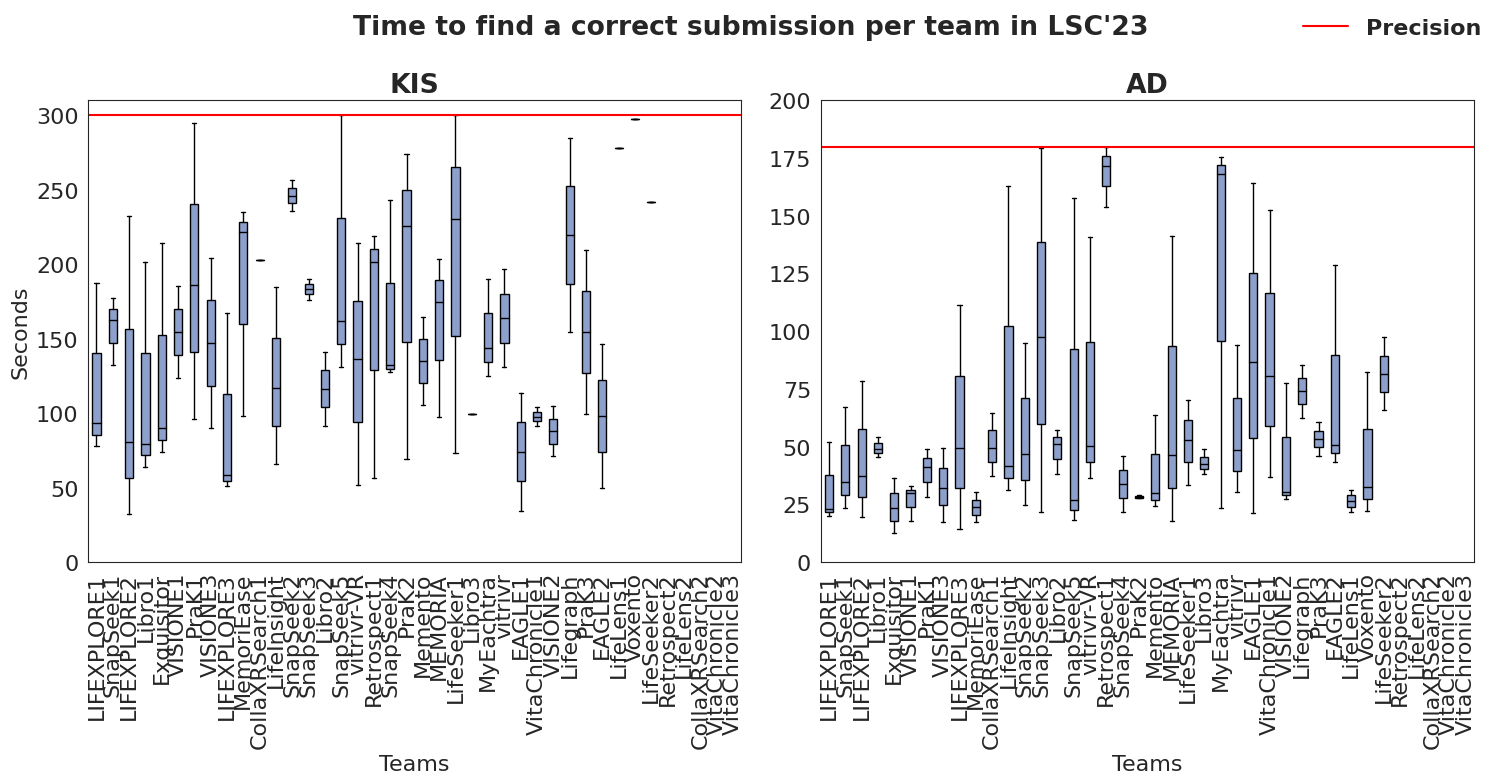

In [28]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(5 + len(task_names) * 5, 8))

# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == TASK]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True,
        ax=axes[i])
    
    # ax.bar_label(ax.containers[0], labels=filtered["precision"], label_type='center')
    # ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Seconds", va='center', rotation='vertical', transform=ax.transAxes)

    # set rotation of x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # add a horizontal line for the limit (with label)
    ax.axhline(y=limits[TASK], color='r', linestyle='-', label=f"Time limit: {limits[TASK]}s")

    if TASK == "KIS":
        ax.set_ylim(0, 310)
    elif TASK == "QA":
        ax.set_ylim(0, 200)
    else:
        ax.set_ylim(0, 200)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')
    


# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Time to find a correct submission per team in LSC'23", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_23.png", format="png", bbox_inches='tight')

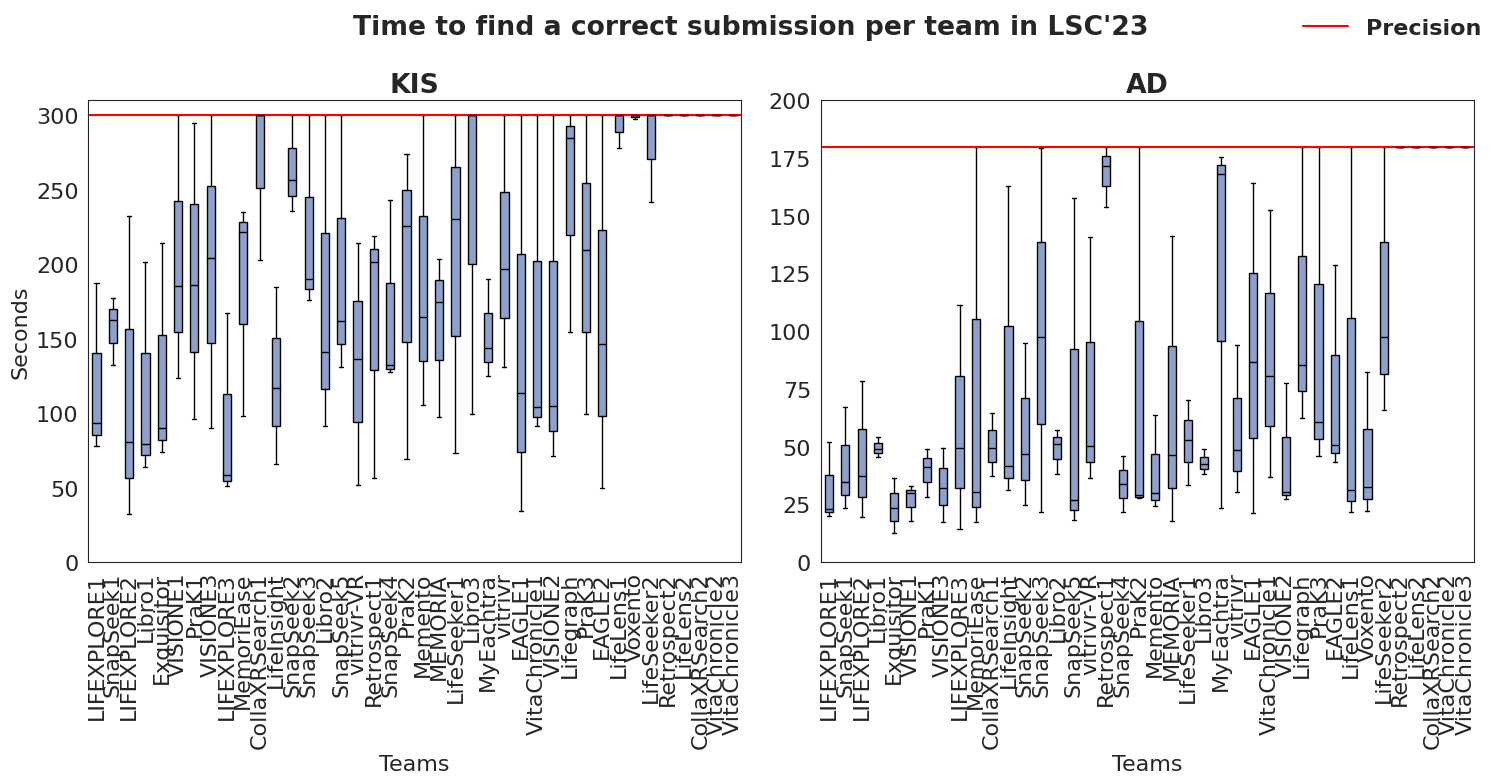

<Figure size 800x800 with 0 Axes>

In [29]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(5 + len(task_names) * 5, 8))

# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[[f"time_correct_full_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == TASK]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True,
        ax=axes[i])
    
    # ax.bar_label(ax.containers[0], labels=filtered["precision"], label_type='center')
    # ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"]], label_type='center')
    # add a horizontal line for the limit (with label)
    ax.axhline(y=limits[TASK], color='r', linestyle='-', label=f"Time limit: {limits[TASK]}s")

    if TASK == "KIS":
        ax.set_ylim(0, 310)
    elif TASK == "QA":
        ax.set_ylim(0, 200)
    else:
        ax.set_ylim(0, 200)
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Seconds", va='center', rotation='vertical', transform=ax.transAxes)

    # set rotation of x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Time to find a correct submission per team in LSC'23", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
plt.show()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_full_23.png", format="png", bbox_inches='tight')